In [61]:
# 1. Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [62]:
# 2. Download and Load Data
url = "https://raw.githubusercontent.com/ShuklaPrashant21/Used-Car-Price-Prediction/master/car%20data.csv"
urllib.request.urlretrieve(url, "car_data.csv")

df = pd.read_csv("car_data.csv")

print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- First 5 Rows ---")
display(df.head())

--- Dataset Shape ---
Rows: 301, Columns: 9

--- First 5 Rows ---


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [63]:
# 3. Data Cleaning & Feature Engineering

# Remove duplicates and missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Standardize categorical values to lowercase to fix inconsistencies
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Feature Engineering 1: Calculate Car Age from Year
df['Car_Age'] = 2024 - df['Year']

# Feature Engineering 2: Extract Brand from Car Name (first word)
df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split(' ')[0].capitalize())

# Inspect the cleaned dataset
print("--- Data Summary After Cleaning ---")
print(f"Remaining Rows: {df.shape[0]}, Columns: {df.shape[1]}")
display(df[['Brand', 'Car_Age', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Transmission']].head())

--- Data Summary After Cleaning ---
Remaining Rows: 299, Columns: 11


,Brand,Car_Age,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Transmission
0,Ritz,10,3.35,5.59,27000,petrol,manual
1,Sx4,11,4.75,9.54,43000,diesel,manual
2,Ciaz,7,7.25,9.85,6900,petrol,manual
3,Wagon,13,2.85,4.15,5200,petrol,manual
4,Swift,10,4.60,6.87,42450,diesel,manual


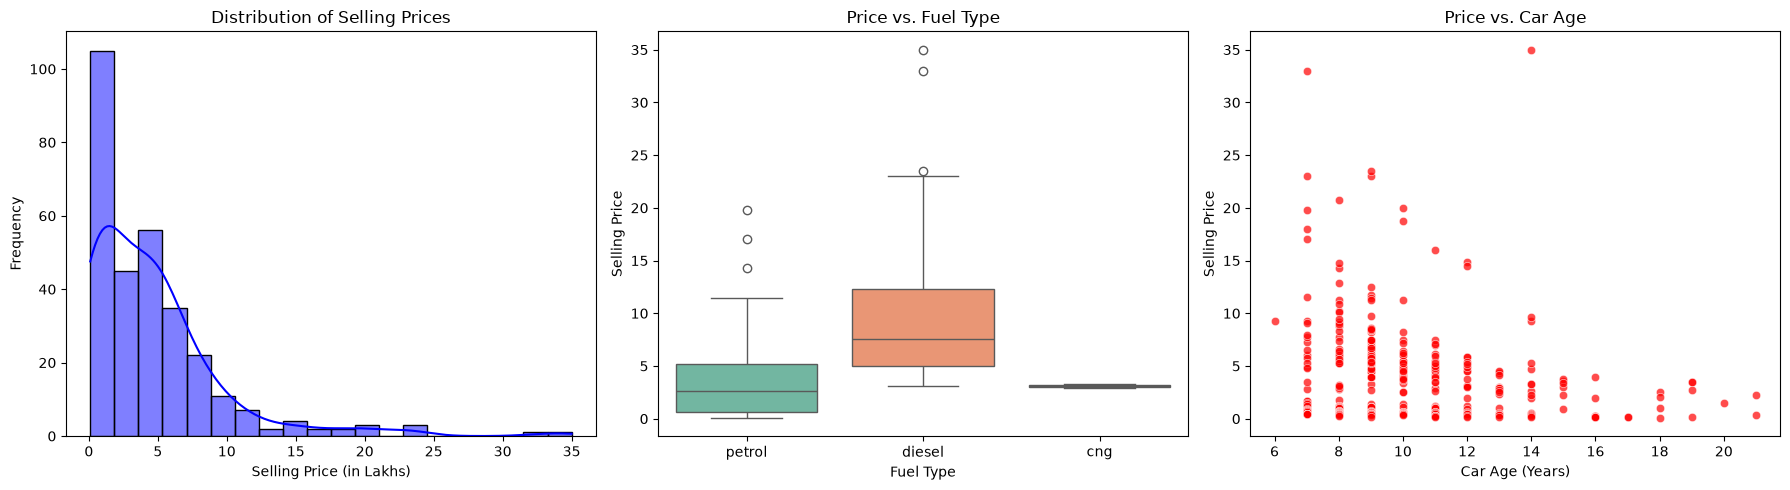

In [64]:
# 4. Exploratory Data Analysis (EDA)
plt.figure(figsize=(18, 5))

# Chart 1: Distribution of Selling Prices
plt.subplot(1, 3, 1)
sns.histplot(df['Selling_Price'], kde=True, color='blue', bins=20)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')

# Chart 2: Price vs. Fuel Type Box Plot
plt.subplot(1, 3, 2)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2', hue='Fuel_Type', legend=False)
plt.title('Price vs. Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

# Chart 3: Price vs. Car Age Scatter Plot
plt.subplot(1, 3, 3)
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df, color='red', alpha=0.7)
plt.title('Price vs. Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')

plt.tight_layout()
plt.show()

--- Data Shape After Encoding ---
Columns expanded from 9 to 52



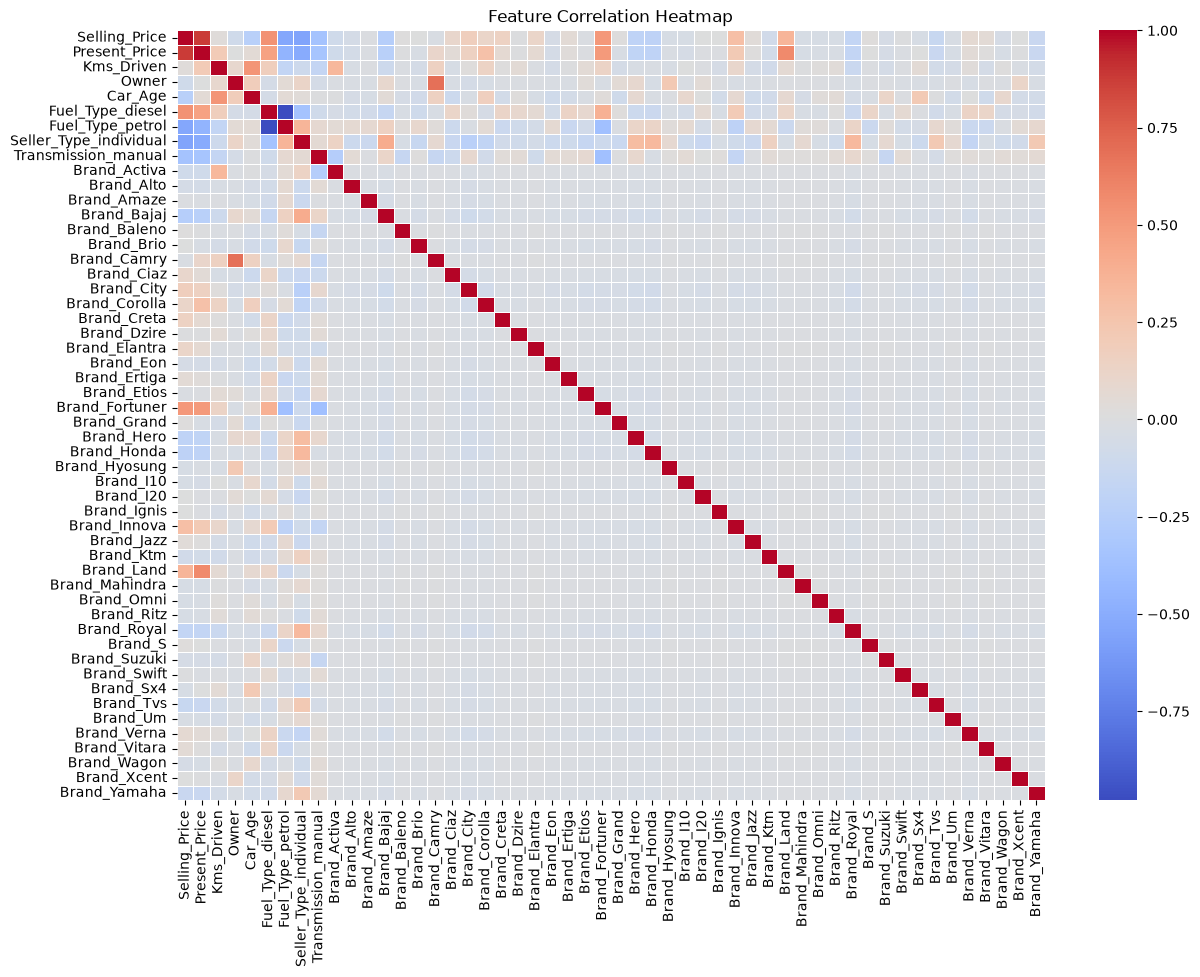

In [65]:
# 5. Drop the raw Car_Name and Year columns (since we engineered Brand and Car_Age)
if 'Car_Name' in df.columns:
    df.drop('Car_Name', axis=1, inplace=True)
if 'Year' in df.columns:
    df.drop('Year', axis=1, inplace=True)

# Encode categorical variables into numbers (0s and 1s)
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand'], drop_first=True, dtype=int)

print("--- Data Shape After Encoding ---")
print(f"Columns expanded from {df.shape[1]} to {df_encoded.shape[1]}\n")

# 6. Feature Correlation Heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df_encoded.corr(numeric_only=True)

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# 7. Train/Test Split
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# Hide 20% of the data to test the models later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Train & Evaluate Models
print("=== MODEL 1: LINEAR REGRESSION ===")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print(f"MAE:  {mean_absolute_error(y_test, lr_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.4f}")
print(f"R² Score: {r2_score(y_test, lr_preds):.4f}\n")

print("=== MODEL 2: RANDOM FOREST REGRESSOR ===")
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")
print(f"R² Score: {r2_score(y_test, rf_preds):.4f}")

=== MODEL 1: LINEAR REGRESSION ===
MAE:  1.3835
RMSE: 2.5699
R² Score: 0.7438

=== MODEL 2: RANDOM FOREST REGRESSOR ===
MAE:  1.3289
RMSE: 3.1707
R² Score: 0.6099


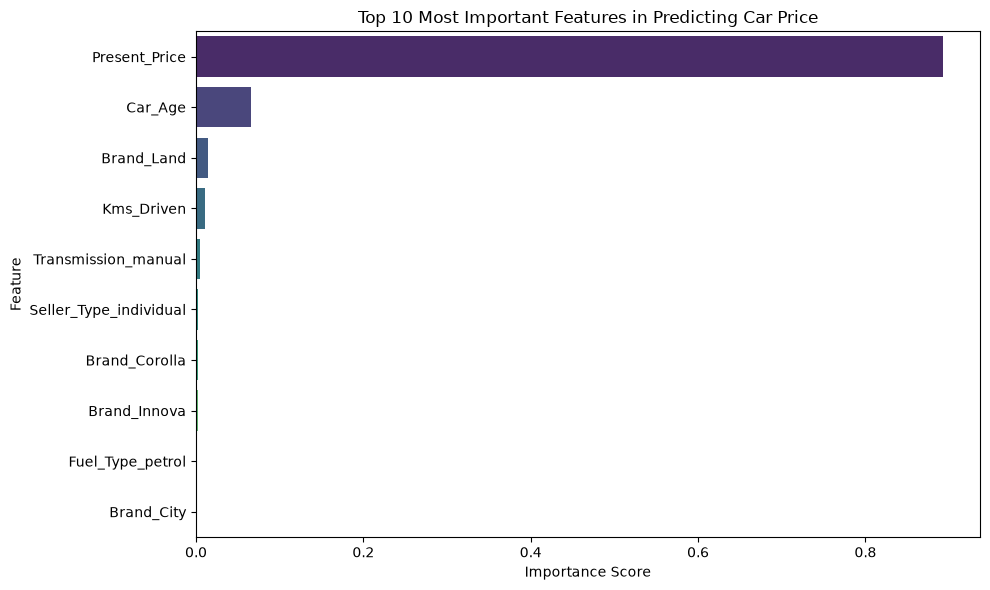

In [67]:
# 9. Feature Importance Chart (Random Forest)
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a clean table of the top 10 most important features
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

# Draw the bar chart (Updated to remove the FutureWarning)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features in Predicting Car Price')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()